# Import Libraries


In [1452]:
# %load_ext autoreload
%reload_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import string
from IPython import display

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import StratifiedKFold

In [1453]:
# params_cfg = {
#     "action"  : "main_feat01",  
#     "seed"    : 42, # Set random seed
#     "exp_dir" : os.path.abspath('../../exps'),
#     'exp_name': 'featbase_07112025',
#     "data_dir": os.path.abspath("../../data/titanic"),
#     "verbose" : True,
# }
params_cfg = {
    "action"   : "train_feat01",  
    "feat_path": "../../exps/featbase_07112025/data.npz",
    "seed"    : 42, # Set random seed
    "exp_dir" : os.path.abspath('../../exps'),
    'exp_name': 'train_07112025',
    "data_dir": os.path.abspath("../../../data"),
    "verbose" : True,
}
params_cfg.update(**{
    "save_dir": os.path.abspath(f'{params_cfg["exp_dir"]}/{params_cfg["exp_name"]}')
})

for v in params_cfg:
    print(f'+ {v}: {params_cfg[v]}')

globals().update(**params_cfg)

+ action: train_feat01
+ feat_path: ../../exps/featbase_07112025/data.npz
+ seed: 42
+ exp_dir: d:\dai_hoc\nam3\HK5\ML\LAB_GROUP\Challenge_2_House_Price\process\exps
+ exp_name: train_07112025
+ data_dir: d:\dai_hoc\nam3\HK5\ML\LAB_GROUP\Challenge_2_House_Price\data
+ verbose: True
+ save_dir: d:\dai_hoc\nam3\HK5\ML\LAB_GROUP\Challenge_2_House_Price\process\exps\train_07112025


# Data Load


In [1454]:
df_train = pd.read_csv(f'{data_dir}/train.csv')
df_test = pd.read_csv(f'{data_dir}/test.csv')

if params_cfg["verbose"]:
    print("-"*10, "information", "-"*10)
    print(f'train-col: {set(df_train.columns)}')
    print(f'test-col: {set(df_test.columns)}')
    print("Union:", set(df_train.columns).intersection(set(df_test.columns)))
    print("Difference:", set(df_train.columns).difference(set(df_test.columns)))

---------- information ----------
train-col: {'Street', 'OverallQual', 'FullBath', 'LotConfig', 'GrLivArea', 'Exterior2nd', 'Fireplaces', 'LandContour', 'BsmtFinSF1', 'EnclosedPorch', '3SsnPorch', 'Utilities', 'GarageQual', 'HouseStyle', 'Alley', 'BedroomAbvGr', 'KitchenQual', 'GarageType', 'MasVnrArea', 'KitchenAbvGr', 'PoolArea', 'ScreenPorch', 'LotShape', 'BsmtFinType2', 'LowQualFinSF', 'Condition2', 'GarageCars', 'BsmtExposure', 'ExterQual', 'RoofStyle', 'BsmtQual', 'SaleType', 'BsmtFullBath', 'Exterior1st', 'MSSubClass', 'Foundation', 'TotRmsAbvGrd', 'Neighborhood', 'BsmtCond', 'MasVnrType', 'RoofMatl', 'LotFrontage', 'OverallCond', 'GarageCond', 'CentralAir', 'GarageYrBlt', 'Electrical', 'FireplaceQu', 'Id', 'WoodDeckSF', 'GarageFinish', 'SaleCondition', 'SalePrice', 'OpenPorchSF', 'YrSold', 'LotArea', 'MiscVal', 'MoSold', 'YearBuilt', 'HeatingQC', 'HalfBath', 'GarageArea', 'Heating', 'PavedDrive', 'Condition1', '1stFlrSF', 'BsmtUnfSF', '2ndFlrSF', 'BsmtFinType1', 'BsmtHalfBath',

# Preprocessing


## Check missing value


In [1455]:
df_train.isna().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [1456]:
df_test.isna().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

## Drop các cột có số lượng missing vượt quá 40%


In [1457]:
def drop_missing_columns(df, threshold=0.4):
    missing_ratio = df.isna().mean()
    missing_columns = missing_ratio[missing_ratio > threshold].index.tolist()
    print(f'Dropping {len(missing_columns)} columns with more than {threshold*100}% missing values.')
    print(f'Columns to drop: {missing_columns}')
    
    # Drop columns and return the modified DataFrame
    df_dropped = df.drop(columns=missing_columns)
    return df_dropped

In [1458]:
df_output = df_train.copy()

In [1459]:
df_output = drop_missing_columns(df_output, threshold=0.4)

Dropping 6 columns with more than 40.0% missing values.
Columns to drop: ['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']


## Drop các cột có nhiều giá trị 0


In [1460]:
def drop_zero_columns(df, threshold=0.5):
    # Calculate ratio of zeros in each column
    zero_ratio = (df == 0).astype(int).mean()
    zero_columns = zero_ratio[zero_ratio > threshold].index.tolist()
    
    print(f'Dropping {len(zero_columns)} columns with more than {threshold*100}% zero values.')
    print(f'Columns to drop: {zero_columns}')
    
    # Drop the columns
    df_dropped = df.drop(columns=zero_columns)
    return df_dropped

In [1461]:
# df_output = drop_zero_columns(df_output, threshold=0.95)

In [1462]:
# fdfd

In [1463]:
df_output

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,Reg,Lvl,AllPub,Inside,...,112,0,0,0,0,4,2010,WD,Normal,142125


## Lọc ra các cột loại number có độ tương quan cao đối với SalePrice (>0.4)


In [1464]:
def engineer_number_columns(df):
    ## Kiểm tra độ tương quan giữa các cột number với SalePrice
    numeric_cols = df_output.select_dtypes(include=[np.number]).columns.tolist()
    correlations = df_output[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
    feature_number = correlations[correlations.abs() > 0.4].index.tolist()
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_output[feature_number].corr(), annot=True, fmt=".2f", cmap='coolwarm')
    np.unique(feature_number)
    return feature_number

## Lọc ra các cột loại object có độ phân bố ít lệch


In [1465]:
def engineer_object_columns(df):
    ## Kiểm tra độ phân bố của các cột object
    object_cols = df_output.select_dtypes(include=['object']).columns.tolist()
    skewed_features = []
    for col in object_cols:
        value_counts = df_output[col].value_counts(normalize=True)
        max_proportion = value_counts.max()
        if max_proportion < 0.7:  # Giả sử ngưỡng là 80%
            skewed_features.append(col)
    print(f'Features with less skewed distribution: {skewed_features}')
    return skewed_features

In [1466]:
def engineer_object_columns1(df):
    features_ob = ['BsmtExposure','BsmtFinType1','BsmtQual','Exterior1st','Exterior2nd','ExterQual','Foundation','GarageFinish','GarageType','HeatingQC','HouseStyle','KitchenQual','LandSlope','LotConfig','LotShape','MSZoning','Neighborhood','RoofStyle','SaleCondition','YrSold']
    return features_ob

In [1467]:
def engineer_object_columns2(df, target_col='SalePrice'):
    object_cols = df.select_dtypes(include=['object']).columns.tolist()
    le = LabelEncoder()
    correlations = {}
    
    for col in object_cols:
        # Encode categorical column
        encoded_col = le.fit_transform(df[col].astype(str))
        # Calculate correlation with target
        corr = np.corrcoef(encoded_col, df[target_col])[0, 1]
        if abs(corr) > 0.2:
            correlations[col] = corr
    
    return correlations

In [1468]:
# Độ tương quan các cột object với SalePrice
def correlate_object_with_target(df, target_col='SalePrice'):
    correlations = engineer_object_columns2(df)
    
    # Convert to Series for easier handling
    corr_series = pd.Series(correlations).sort_values(ascending=False)
    print("Correlation of object columns with target:")
    print(corr_series)
    return corr_series

correlate_object_with_target(df_output, target_col='SalePrice')

Correlation of object columns with target:
Foundation       0.382479
CentralAir       0.251328
Electrical       0.234716
PavedDrive       0.231357
RoofStyle        0.222405
SaleCondition    0.213092
Neighborhood     0.210851
LotShape        -0.255580
BsmtExposure    -0.309043
HeatingQC       -0.400178
GarageType      -0.415283
GarageFinish    -0.549247
KitchenQual     -0.589189
BsmtQual        -0.620886
ExterQual       -0.636884
dtype: float64


Foundation       0.382479
CentralAir       0.251328
Electrical       0.234716
PavedDrive       0.231357
RoofStyle        0.222405
SaleCondition    0.213092
Neighborhood     0.210851
LotShape        -0.255580
BsmtExposure    -0.309043
HeatingQC       -0.400178
GarageType      -0.415283
GarageFinish    -0.549247
KitchenQual     -0.589189
BsmtQual        -0.620886
ExterQual       -0.636884
dtype: float64

<Figure size 1000x600 with 0 Axes>

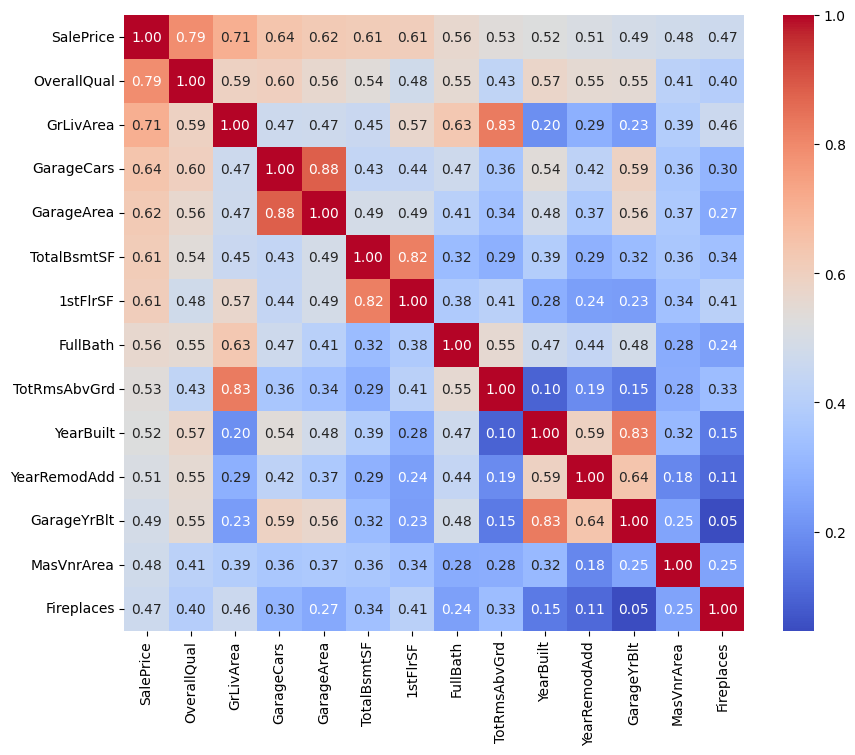

In [1469]:
plt.figure(figsize=(10, 6))
final_feature = engineer_number_columns(df_output) + list(engineer_object_columns2(df_output).keys())

In [1470]:
len(final_feature)

29

# Feature Engineering


In [1471]:
np.unique(final_feature)

array(['1stFlrSF', 'BsmtExposure', 'BsmtQual', 'CentralAir', 'Electrical',
       'ExterQual', 'Fireplaces', 'Foundation', 'FullBath', 'GarageArea',
       'GarageCars', 'GarageFinish', 'GarageType', 'GarageYrBlt',
       'GrLivArea', 'HeatingQC', 'KitchenQual', 'LotShape', 'MasVnrArea',
       'Neighborhood', 'OverallQual', 'PavedDrive', 'RoofStyle',
       'SaleCondition', 'SalePrice', 'TotRmsAbvGrd', 'TotalBsmtSF',
       'YearBuilt', 'YearRemodAdd'], dtype='<U13')

In [1472]:
df_output[final_feature].isna().sum()


SalePrice         0
OverallQual       0
GrLivArea         0
GarageCars        0
GarageArea        0
TotalBsmtSF       0
1stFlrSF          0
FullBath          0
TotRmsAbvGrd      0
YearBuilt         0
YearRemodAdd      0
GarageYrBlt      81
MasVnrArea        8
Fireplaces        0
LotShape          0
Neighborhood      0
RoofStyle         0
ExterQual         0
Foundation        0
BsmtQual         37
BsmtExposure     38
HeatingQC         0
CentralAir        0
Electrical        1
KitchenQual       0
GarageType       81
GarageFinish     81
PavedDrive        0
SaleCondition     0
dtype: int64

In [ ]:
def prepare_features(train_df, test_df, target_col="SalePrice"):
    train_df = train_df.copy()
    test_df = test_df.copy()

    # ---- chọn các cột gốc cần dùng (khoảng 33 cột + vài cột FE)
    base_cols = [
        'MSZoning','LotArea','LotConfig','LandSlope','Neighborhood',
        'HouseStyle','OverallQual','YearBuilt','YearRemodAdd',
        'RoofStyle','Exterior1st','Exterior2nd','ExterQual','Foundation',
        'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','TotalBsmtSF',
        'HeatingQC','CentralAir','1stFlrSF','GrLivArea','FullBath',
        'TotRmsAbvGrd','GarageType','GarageFinish','GarageCars','GarageArea',
        'PavedDrive','MoSold','YrSold','SaleType','SaleCondition'
    ]

    # đôi khi 1 số cột sau khi drop ở trên sẽ mất → chỉ giữ cột còn tồn tại
    base_cols = [c for c in base_cols if c in train_df.columns]

    # lấy train_X
    train_X = train_df[base_cols].copy()
    # lấy test_X
    test_X = test_df[[c for c in base_cols if c in test_df.columns]].copy()

    # =============================
    # 4.1 MAP / RÚT GỌN CÁC CỘT CATEGORICAL
    # =============================

    # BsmtFinType1
    col_BsmtFinType1 = {'Unf': 1, 'GLQ': 2, 'ALQ': 3, 'BLQ': 3, 'Rec': 3, 'LwQ': 3}
    for df in [train_X, test_X]:
        if 'BsmtFinType1' in df.columns:
            df['BsmtFinType1'] = df['BsmtFinType1'].map(col_BsmtFinType1).fillna(4)

    # BsmtExposure
    col_BsmtExposure = {'No': 1, 'Av': 2, 'Mn': 2, 'Gd': 3}
    for df in [train_X, test_X]:
        if 'BsmtExposure' in df.columns:
            df['BsmtExposure'] = df['BsmtExposure'].map(col_BsmtExposure).fillna(4)

    # BsmtQual
    col_BsmtQual = {'TA':1, 'Fa':1, 'Gd':2, 'Ex':3}
    for df in [train_X, test_X]:
        if 'BsmtQual' in df.columns:
            df['BsmtQual'] = df['BsmtQual'].map(col_BsmtQual)

    # Exterior1st
    for df in [train_X, test_X]:
        if 'Exterior1st' in df.columns:
            df['Exterior1st'] = df['Exterior1st'].apply(
                lambda x: x if x in ['VinylSd','MetalSd','Wd Sdng','HdBoard','Plywood','Stucco'] else 'others'
            )
            map_ex1 = {'VinylSd':1, 'MetalSd':2, 'Wd Sdng':2, 'HdBoard':2, 'Plywood':2, 'Stucco':2, 'others':3}
            df['Exterior1st'] = df['Exterior1st'].map(map_ex1)

    # Exterior2nd
    for df in [train_X, test_X]:
        if 'Exterior2nd' in df.columns:
            df['Exterior2nd'] = df['Exterior2nd'].apply(
                lambda x: x if x in ['VinylSd','MetalSd','HdBoard','Wd Sdng','Plywood'] else 'others'
            )
            map_ex2 = {'VinylSd':1, 'MetalSd':2, 'HdBoard':3, 'Wd Sdng':4, 'Plywood':5, 'others':6}
            df['Exterior2nd'] = df['Exterior2nd'].map(map_ex2)

    # ExterQual
    for df in [train_X, test_X]:
        if 'ExterQual' in df.columns:
            df['ExterQual'] = df['ExterQual'].apply(lambda x: x if x in ['TA','Gd'] else 'others')
            map_exq = {'TA':1, 'Gd':2, 'others':3}
            df['ExterQual'] = df['ExterQual'].map(map_exq)

    # Foundation
    for df in [train_X, test_X]:
        if 'Foundation' in df.columns:
            df['Foundation'] = df['Foundation'].apply(lambda x: x if x in ['PConc','CBlock','BrkTil'] else 'others')
            map_f = {'PConc':1, 'CBlock':2, 'BrkTil':3, 'others':4}
            df['Foundation'] = df['Foundation'].map(map_f)

    # GarageFinish
    for df in [train_X, test_X]:
        if 'GarageFinish' in df.columns:
            df['GarageFinish'] = df['GarageFinish'].fillna('others')
            map_gf = {'Unf':1, 'RFn':2, 'Fin':3, 'others':4}
            df['GarageFinish'] = df['GarageFinish'].map(map_gf)

    # GarageType
    for df in [train_X, test_X]:
        if 'GarageType' in df.columns:
            df['GarageType'] = df['GarageType'].apply(lambda x: x if x in ['Attchd','Detchd'] else 'others')
            map_gt = {'Attchd':1, 'Detchd':2, 'others':3}
            df['GarageType'] = df['GarageType'].map(map_gt)

    # HeatingQC
    for df in [train_X, test_X]:
        if 'HeatingQC' in df.columns:
            df['HeatingQC'] = df['HeatingQC'].apply(lambda x: x if x in ['Ex','TA','Gd'] else 'others')
            map_hq = {'Ex':1, 'TA':2, 'Gd':3, 'others':4}
            df['HeatingQC'] = df['HeatingQC'].map(map_hq)

    # HouseStyle
    for df in [train_X, test_X]:
        if 'HouseStyle' in df.columns:
            df['HouseStyle'] = df['HouseStyle'].apply(lambda x: x if x in ['1Story','2Story','1.5Fin'] else 'others')
            map_hs = {'1Story':1, '2Story':2, '1.5Fin':3, 'others':4}
            df['HouseStyle'] = df['HouseStyle'].map(map_hs)

    # KitchenQual nếu có
    for df in [train_X, test_X]:
        if 'KitchenQual' in df.columns:
            df['KitchenQual'] = df['KitchenQual'].apply(lambda x: x if x in ['TA','Gd','Ex'] else 'others')
            map_kq = {'TA':1, 'Gd':2, 'Ex':3, 'others':4}
            df['KitchenQual'] = df['KitchenQual'].map(map_kq)

    # LandSlope: bạn drop vì lệch → drop luôn
    for df in [train_X, test_X]:
        if 'LandSlope' in df.columns:
            df.drop(columns=['LandSlope'], inplace=True)

    # LotConfig
    for df in [train_X, test_X]:
        if 'LotConfig' in df.columns:
            df['LotConfig'] = df['LotConfig'].apply(lambda x: x if x in ['Inside','Corner'] else 'others')
            map_lc = {'Inside':1, 'Corner':2, 'others':3}
            df['LotConfig'] = df['LotConfig'].map(map_lc)

    # LotShape
    for df in [train_X, test_X]:
        if 'LotShape' in df.columns:
            df['LotShape'] = df['LotShape'].apply(lambda x: x if x in ['Reg','IR1'] else 'others')
            map_ls = {'Reg':1, 'IR1':2, 'others':3}
            df['LotShape'] = df['LotShape'].map(map_ls)

    # MSZoning
    for df in [train_X, test_X]:
        if 'MSZoning' in df.columns:
            df['MSZoning'] = df['MSZoning'].apply(lambda x: x if x in ['RL','RM'] else 'others')
            map_ms = {'RL':1, 'RM':2, 'others':3}
            df['MSZoning'] = df['MSZoning'].map(map_ms)

    # RoofStyle
    for df in [train_X, test_X]:
        if 'RoofStyle' in df.columns:
            df['RoofStyle'] = df['RoofStyle'].apply(lambda x: x if x in ['Gable','Hip'] else 'others')
            map_rs = {'Gable':1, 'Hip':2, 'others':3}
            df['RoofStyle'] = df['RoofStyle'].map(map_rs)

    # SaleCondition
    for df in [train_X, test_X]:
        if 'SaleCondition' in df.columns:
            df['SaleCondition'] = df['SaleCondition'].apply(
                lambda x: x if x in ['Normal','Partial','Abnorml'] else 'others'
            )
            map_sc = {'Normal':1, 'Partial':2, 'Abnorml':3, 'others':4}
            df['SaleCondition'] = df['SaleCondition'].map(map_sc)

    # ============== Neighborhood: target-mean encoding thủ công ==============
    if 'Neighborhood' in train_X.columns:
        nb_mean = train_df.groupby('Neighborhood')[target_col].mean()
        # map train
        train_X['Neighborhood'] = train_X['Neighborhood'].map(nb_mean)
        # test: nếu ko có trong train → fill bằng mean chung
        global_mean = train_df[target_col].mean()
        test_X['Neighborhood'] = test_X['Neighborhood'].map(nb_mean).fillna(global_mean)

        # scale
        scaler_nb = StandardScaler()
        train_X[['Neighborhood']] = scaler_nb.fit_transform(train_X[['Neighborhood']])
        test_X[['Neighborhood']] = scaler_nb.transform(test_X[['Neighborhood']])

    # ============== Feature engineering numeric ===============
    # HouseAge = YrSold - YearBuilt
    if ('YrSold' in train_X.columns) and ('YearBuilt' in train_X.columns):
        train_X['HouseAge'] = train_X['YrSold'] - train_X['YearBuilt']
        test_X['HouseAge'] = test_X['YrSold'] - test_X['YearBuilt']
        scaler_age = StandardScaler()
        train_X[['HouseAge']] = scaler_age.fit_transform(train_X[['HouseAge']])
        test_X[['HouseAge']] = scaler_age.transform(test_X[['HouseAge']])

    # IsRemodeled
    if ('YearRemodAdd' in train_X.columns) and ('YearBuilt' in train_X.columns):
        train_X['IsRemodeled'] = (train_X['YearRemodAdd'] != train_X['YearBuilt']).astype(int)
        test_X['IsRemodeled'] = (test_X['YearRemodAdd'] != test_X['YearBuilt']).astype(int)

    # Scale mấy cột liên tục quan trọng
    for col in ['TotalBsmtSF','1stFlrSF','GrLivArea','LotArea','GarageArea']:
        if col in train_X.columns:
            scaler_tmp = StandardScaler()
            train_X[[col]] = scaler_tmp.fit_transform(train_X[[col]])
            if col in test_X.columns:
                test_X[[col]] = scaler_tmp.transform(test_X[[col]])

    # Has3FullBath
    if 'FullBath' in train_X.columns:
        train_X['Has3FullBath'] = (train_X['FullBath'] >= 3).astype(int)
        test_X['Has3FullBath'] = (test_X['FullBath'] >= 3).astype(int)

    # Has3Garage
    if 'GarageCars' in train_X.columns:
        train_X['Has3Garage'] = (train_X['GarageCars'] == 3).astype(int)
        test_X['Has3Garage'] = (test_X['GarageCars'] == 3).astype(int)

    # GarageArea_per_car
    if ('GarageArea' in train_X.columns) and ('GarageCars' in train_X.columns):
        train_X['GarageArea_per_car'] = train_X['GarageArea'] / (train_X['GarageCars'] + 1)
        test_X['GarageArea_per_car'] = test_X['GarageArea'] / (test_X['GarageCars'] + 1)
        scaler_g = StandardScaler()
        train_X[['GarageArea','GarageArea_per_car']] = scaler_g.fit_transform(
            train_X[['GarageArea','GarageArea_per_car']]
        )
        test_X[['GarageArea','GarageArea_per_car']] = scaler_g.transform(
            test_X[['GarageArea','GarageArea_per_car']]
        )

    # cuối cùng: drop mấy cột gốc ko cần nữa
    drop_cols = ['YearBuilt','YrSold','YearRemodAdd','TotRmsAbvGrd']
    for df in [train_X, test_X]:
        for c in drop_cols:
            if c in df.columns:
                df.drop(columns=[c], inplace=True)

    # =============================
    # 4.2 Encode mọi object còn sót (phòng hờ)
    # =============================
    for df in [train_X, test_X]:
        obj_cols = df.select_dtypes(include='object').columns
        for col in obj_cols:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))

    # gắn lại target
    train_X[target_col] = train_df[target_col].values

    return train_X, test_X


train_X, test_X = prepare_features(train_clean, test_clean, target_col="SalePrice")

# Main


In [1552]:
def main_feat01(**kwargs):
    # load data
    df_train = pd.read_csv(f'{data_dir}/train.csv')
    df_test = pd.read_csv(f'{data_dir}/test.csv')
    # preprocessing
    df_output_train, _ = preprocessing_feature_01(df_train, is_train=True, is_debug=False)
    df_output_test, _ = preprocessing_feature_01(df_test, is_train=False, is_debug=False)
    # Encoder Neighborhood with Target Encoder
    
    df_output_train, df_output_test = target_encode_feature_(df_output_train, df_output_test, feature_name='Neighborhood', target_name='Output')
    df_output_train, df_output_test = scale_features(df_output_train, df_output_test, feature_list=final_feature)
    # saving
    os.makedirs(save_dir, exist_ok=True)
    
    # Lưu trực tiếp DataFrame objects (cần allow_pickle=True khi load)
    np.savez(f'{save_dir}/data.npz', 
             train_data=df_output_train.values,
             test_data=df_output_test.values,
             train_columns=df_output_train.columns.values,  # Lưu tên cột train
             test_columns=df_output_test.columns.values,
             allow_pickle=True)
    
    print("Đã lưu DataFrame với đầy đủ thông tin cột")

    kwargs.get('global_cfg', {}).update(**locals())

if params_cfg["action"] == "train_feat01":
    print("Runing ... [train_feat01]")
    main_feat01(global_cfg = globals())

Runing ... [train_feat01]
Column LotFrontage: 259 missing values
Column Alley: 1369 missing values
Column MasVnrType: 872 missing values
Column MasVnrArea: 8 missing values
Column BsmtQual: 37 missing values
Column BsmtCond: 37 missing values
Column BsmtExposure: 38 missing values
Column BsmtFinType1: 37 missing values
Column BsmtFinType2: 38 missing values
Column Electrical: 1 missing values
Column FireplaceQu: 690 missing values
Column GarageType: 81 missing values
Column GarageYrBlt: 81 missing values
Column GarageFinish: 81 missing values
Column GarageQual: 81 missing values
Column GarageCond: 81 missing values
Column PoolQC: 1453 missing values
Column Fence: 1179 missing values
Column MiscFeature: 1406 missing values
Column MSZoning: 4 missing values
Column LotFrontage: 227 missing values
Column Alley: 1352 missing values
Column Utilities: 2 missing values
Column Exterior1st: 1 missing values
Column Exterior2nd: 1 missing values
Column MasVnrType: 894 missing values
Column MasVnrA

# End
